### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
* Tracking agent behavior with logging, analytics, and debugging.
* Transforming prompts, tool selection, and output formatting.
* Adding retries, fallbacks, and early termination logic.
* Applying rate limits, guardrails, and PII detection.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True


### Summarization MiddleWare

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
* Long-running conversations that exceed context windows.
* Multi-turn dialogues with extensive history.
* Applications where preserving full conversation context matters.

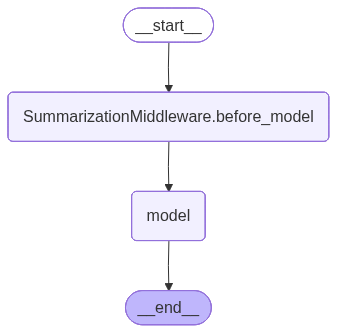

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, SystemMessage

# agent with Message based summarization

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("messages", 10), # When message count exceeds 10: summarize old conversation
            keep=("messages", 4), # Keep latest 4 raw messages unchanged. Older messages become: compressed summary
        )
    ],
)

agent


In [5]:
## thread id for unique session id

config={"configurable": {"thread_id": "test1"}}

In [ ]:
# each question adds 1 HumanMessage
# each answer adds 1 AIMessage

questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for question in questions:
    response = agent.invoke({"messages": [HumanMessage(content=question)]}, config=config)
    print(f"Messages: {response}")
    print(f"Length of Messages: {len(response['messages'])}") 


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='de12dbeb-4f8b-4e87-a740-b936b2182ff3'), AIMessage(content='<think>\nOkay, the user asked, "What is 2+2?" Let me think about how to approach this. First, this is a simple arithmetic problem, so the answer is straightforward. But maybe the user is testing if I can handle basic math or if there\'s a trick here. Let me double-check.\n\nAddition of 2 and 2. In decimal system, 2 plus 2 equals 4. That\'s the standard answer. But wait, could there be any context where the answer isn\'t 4? Like in different number systems or units? For example, in binary, 2 isn\'t a valid digit, but if it\'s base 3 or higher, 2+2 would still be 4. Wait, base 3 can have digits up to 2, so 2+2 in base 3 would be 11 (which is 4 in decimal). But the question doesn\'t specify a base, so it\'s safe to assume base 10. \n\nAlternatively, maybe the user is thinking of a wordplay or a trick question. Like, "2+2" a

#### You can also mention token_size or fraction (when 5% of model's max token limit is reached, summarize) in the trigger instead of messages length. 



### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
* High-stakes operations requiring human approval (e.g. database writes, financial transactions).
* Compliance workflows where human oversight is mandatory.
* Long-running conversations where human feedback guides the agent.

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware 
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str: 
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

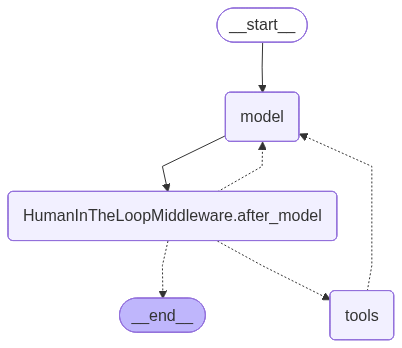

In [13]:
agent = create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer=InMemorySaver(),
    tools=[read_email_tool, send_email_tool],
    middleware=[HumanInTheLoopMiddleware(
        interrupt_on={
            "send_email_tool": {
                "allowed_decisions": ["approve", "edit", "reject"],
            },
            "read_email_tool": False
        }
    )],
)

agent

In [18]:
config = {"configurable": {"thread_id": "test1"}}

In [22]:
result = agent.invoke(
    {"messages": [HumanMessage(content="Send an email to chethan@example.com with subject 'Test Email' and body 'This is a test email.'")]},
    config=config,
)

result

{'messages': [HumanMessage(content="Send an email to chethan@example.com with subject 'Test Email' and body 'This is a test email.'", additional_kwargs={}, response_metadata={}, id='29e95918-9a92-4a00-9085-bfad9fc59fbc'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's see. The user wants to send an email to chethan@example.com with the subject 'Test Email' and the body 'This is a test email.' I need to check the available tools to see which one can handle this.\n\nLooking at the tools provided, there's the send_email_tool. Its parameters are recipient, subject, body, all required. The user provided all three: recipient is chethan@example.com, subject is 'Test Email', and body is 'This is a test email.' \n\nSo I should call the send_email_tool with those exact parameters. There's no need to use the read_email_tool here since the task is about sending, not reading. The parameters match, so the function call should be straightforward. Just make sure the JSON 

In [16]:
from langgraph.types import Command

## Step 1: Approve

if "__interrupt__" in result:
    print("Approving")

    result = agent.invoke(
        Command(
            resume = {
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Approving
Result: The email has been successfully sent to chethan@example.com with the subject "Test Email". Let me know if you need anything else!


In [20]:
## Reject

if "__interrupt__" in result:
    print("Rejecting")

    result = agent.invoke(
        Command(
            resume = {
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

    

Rejecting
Result: It seems there was an issue processing the request to send the email (rejection ID: `rqjy9whv7`). Would you like to:

1. **Try sending the email again** with the same details?  
2. **Modify the email content** slightly to avoid duplication?  
3. **Investigate the error** further (e.g., check logs for rejection reasons)?  

Let me know how you'd like to proceed!


In [23]:
## Editing

if "__interrupt__" in result:
    print("Editing")

    result = agent.invoke(
        Command(
            resume = {
                "decisions": [
                    {
                        "type": "edit", 
                        "edited_action": {
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "chethan@example.com",
                                "subject": "Edited Email",
                                "body": "This is a test email after editing."
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Editing
Result: The email has been sent to **chethan@example.com** with the subject **"Edited Email"** and the body **"This is a test email after editing."**  

Would you like to:  
1. **Resend the original email** with the exact subject and body ("Test Email" / "This is a test email")?  
2. Make **further adjustments** to the email content?  

Let me know!
